# Day 28 — Time Series Basics
### Datetime Indexing · Decomposition · Rolling Stats · ARIMA Introduction

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

# Install statsmodels if needed
try:
    import statsmodels

    print(f"statsmodels: {statsmodels.__version__} ✅")
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "statsmodels"], capture_output=True)
    import statsmodels

    print(f"statsmodels: {statsmodels.__version__} ✅ (just installed)")

# Create realistic time series — monthly Titanic-era passenger counts
np.random.seed(42)
dates = pd.date_range("2020-01-01", periods=48, freq="MS")
trend = np.linspace(100, 180, 48)
seasonality = 20 * np.sin(2 * np.pi * np.arange(48) / 12)
noise = np.random.normal(0, 8, 48)
passengers = trend + seasonality + noise

ts = pd.Series(passengers, index=dates, name="Passengers")

print(f"statsmodels: {statsmodels.__version__} ✅")
print(f"\nTime Series: {len(ts)} monthly observations")
print(f"Date range: {ts.index[0].date()} to {ts.index[-1].date()}")
print(f"Mean: {ts.mean():.1f} | Std: {ts.std():.1f}")
print(f"Min: {ts.min():.1f} | Max: {ts.max():.1f}")
print("\nFirst 6 values:")
print(ts.head(6))
print("Ready! ✅")

statsmodels: 0.14.6 ✅
statsmodels: 0.14.6 ✅

Time Series: 48 monthly observations
Date range: 2020-01-01 to 2023-12-01
Mean: 138.4 | Std: 25.0
Min: 92.5 | Max: 191.3

First 6 values:
2020-01-01    103.973713
2020-02-01    110.596013
2020-03-01    125.906272
2020-04-01    137.290622
2020-05-01    122.255792
2020-06-01    116.637543
Freq: MS, Name: Passengers, dtype: float64
Ready! ✅


## 2. What is Time Series?

          WHAT IS TIME SERIES?

A time series is a sequence of data points collected
at regular time intervals.

EXAMPLES:
  - Stock prices (daily)
  - Monthly sales revenue
  - Hourly website traffic
  - Annual GDP growth
  - Weekly passenger counts

KEY COMPONENTS:
  1. TREND      — long-term direction (up/down/flat)
  2. SEASONALITY — repeating patterns at fixed intervals
  3. CYCLICAL   — longer irregular fluctuations
  4. RESIDUAL   — random noise remaining after above

KEY DIFFERENCES from regular ML:
  - Order MATTERS — time sequence is crucial
  - Cannot shuffle data — past predicts future
  - Cannot use future data to predict past (leakage!)
  - Special train/test split — always use time-based split

STATIONARITY — crucial concept:
  A stationary series has:
  - Constant mean over time
  - Constant variance over time
  - No trend or seasonality
  Most time series models require stationary input!



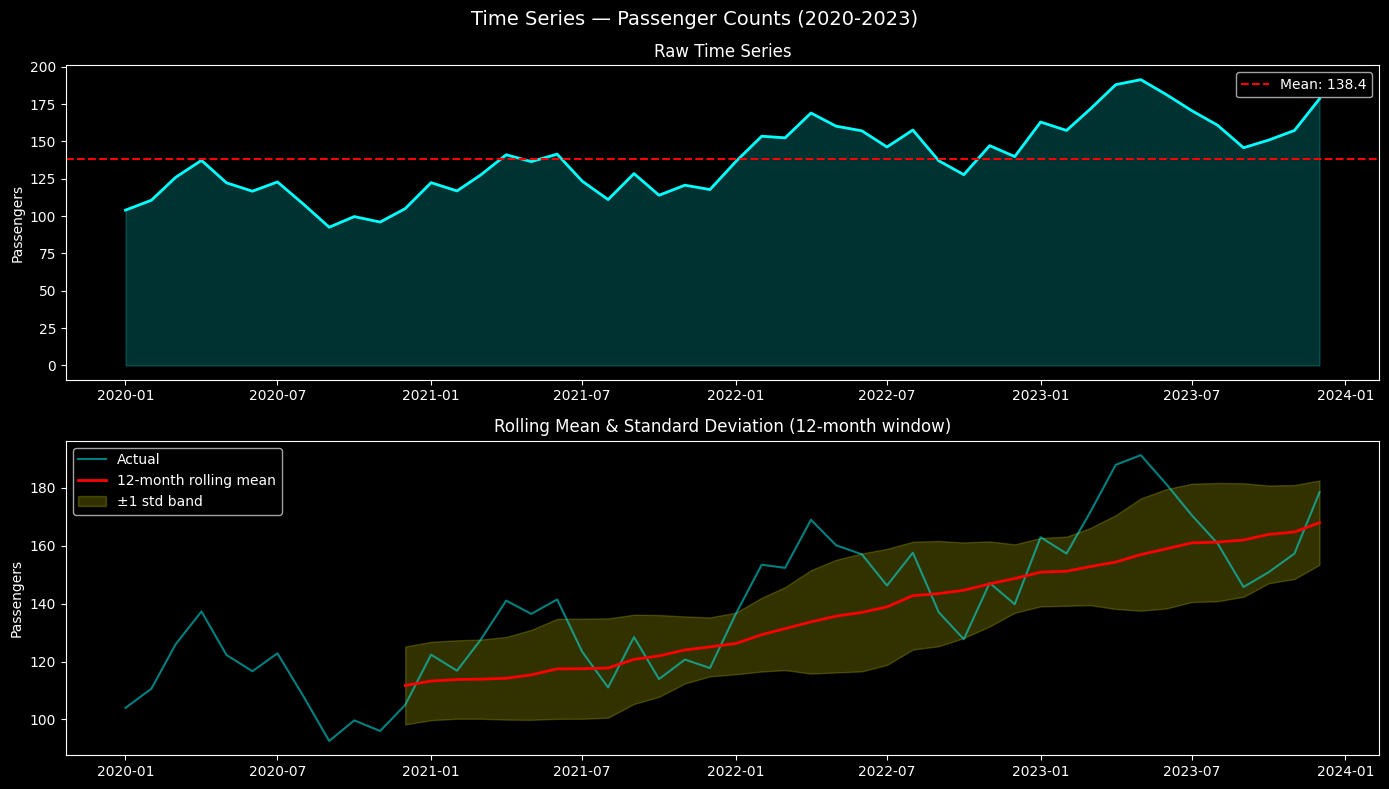


Rolling Statistics (last 3 months):
Month           Value      12m Mean     12m Std
---------------------------------------------
2023-10-01      150.8      163.9        16.9
2023-11-01      157.3      164.8        16.2
2023-12-01      178.5      168.0        14.6


In [ ]:
print("=" * 55)
print("          WHAT IS TIME SERIES?")
print("=" * 55)
print("""
A time series is a sequence of data points collected
at regular time intervals.

EXAMPLES:
  - Stock prices (daily)
  - Monthly sales revenue
  - Hourly website traffic
  - Annual GDP growth
  - Weekly passenger counts

KEY COMPONENTS:
  1. TREND      — long-term direction (up/down/flat)
  2. SEASONALITY — repeating patterns at fixed intervals
  3. CYCLICAL   — longer irregular fluctuations
  4. RESIDUAL   — random noise remaining after above

KEY DIFFERENCES from regular ML:
  - Order MATTERS — time sequence is crucial
  - Cannot shuffle data — past predicts future
  - Cannot use future data to predict past (leakage!)
  - Special train/test split — always use time-based split

STATIONARITY — crucial concept:
  A stationary series has:
  - Constant mean over time
  - Constant variance over time
  - No trend or seasonality
  Most time series models require stationary input!
""")

# Plot the raw time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Time Series — Passenger Counts (2020-2023)", fontsize=14)

axes[0].plot(ts.index, ts.values, color="cyan", linewidth=2)
axes[0].fill_between(ts.index, ts.values, alpha=0.2, color="cyan")
axes[0].set_title("Raw Time Series")
axes[0].set_ylabel("Passengers")
axes[0].axhline(ts.mean(), color="red", linestyle="--", label=f"Mean: {ts.mean():.1f}")
axes[0].legend()

# Rolling statistics
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

axes[1].plot(ts.index, ts.values, color="cyan", alpha=0.5, label="Actual")
axes[1].plot(
    rolling_mean.index,
    rolling_mean.values,
    color="red",
    linewidth=2,
    label="12-month rolling mean",
)
axes[1].fill_between(
    ts.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    alpha=0.2,
    color="yellow",
    label="±1 std band",
)
axes[1].set_title("Rolling Mean & Standard Deviation (12-month window)")
axes[1].set_ylabel("Passengers")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRolling Statistics (last 3 months):")
print(f"{'Month':<15} {'Value':<10} {'12m Mean':<12} {'12m Std'}")
print("-" * 45)
for date in ts.index[-3:]:
    print(
        f"{str(date.date()):<15} {ts[date]:<10.1f} "
        f"{rolling_mean[date]:<12.1f} {rolling_std[date]:.1f}"
    )

## 3. Time Series Decomposition

      TIME SERIES DECOMPOSITION

Decomposition separates a time series into its components:
  Observed = Trend + Seasonality + Residual (additive)
  Observed = Trend × Seasonality × Residual (multiplicative)

USE ADDITIVE when: seasonal variation is CONSTANT
USE MULTIPLICATIVE when: seasonal variation GROWS with trend



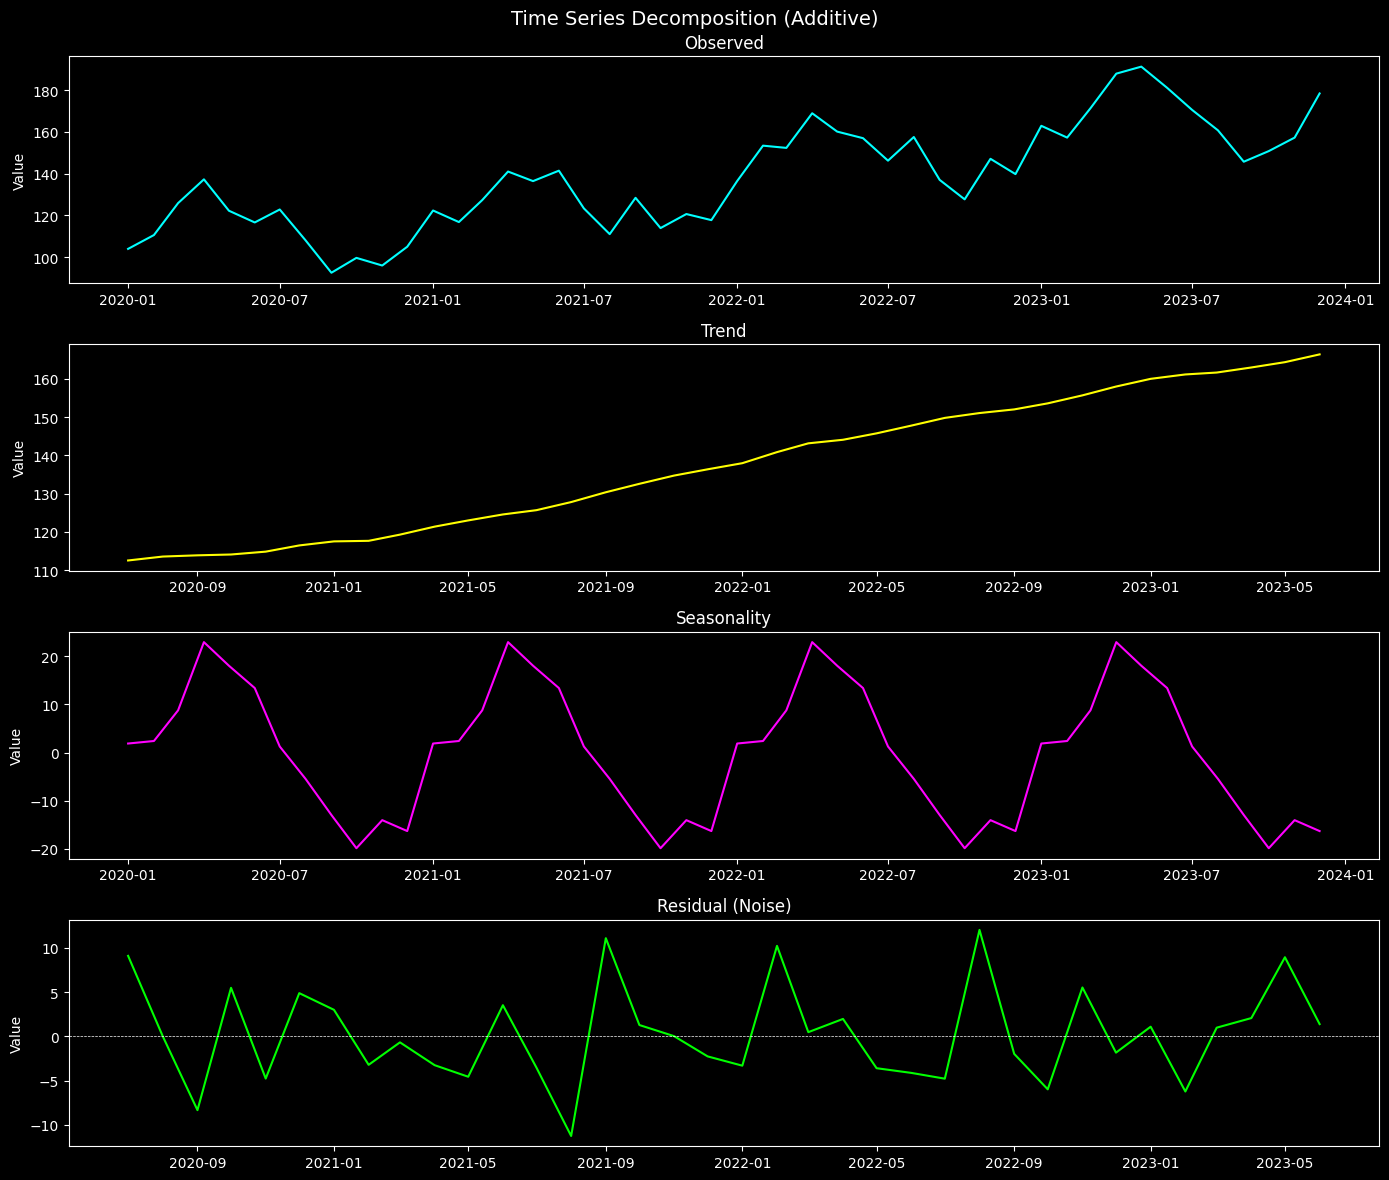


Seasonal Pattern (monthly factors):
  Jan: +1.88 ↑ █
  Feb: +2.40 ↑ ██
  Mar: +8.77 ↑ ████████
  Apr: +22.94 ↑ ██████████████████████
  May: +18.04 ↑ ██████████████████
  Jun: +13.40 ↑ █████████████
  Jul: +1.26 ↑ █
  Aug: -5.47 ↓ █████
  Sep: -12.97 ↓ ████████████
  Oct: -19.88 ↓ ███████████████████
  Nov: -14.05 ↓ ██████████████
  Dec: -16.32 ↓ ████████████████

Trend range: 112.5 to 166.4
Residual std: 5.54 (should be small)


In [ ]:
print("=" * 55)
print("      TIME SERIES DECOMPOSITION")
print("=" * 55)
print("""
Decomposition separates a time series into its components:
  Observed = Trend + Seasonality + Residual (additive)
  Observed = Trend × Seasonality × Residual (multiplicative)

USE ADDITIVE when: seasonal variation is CONSTANT
USE MULTIPLICATIVE when: seasonal variation GROWS with trend
""")

# Decompose
decomposition = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("Time Series Decomposition (Additive)", fontsize=14)

components = [
    (ts, "Observed", "cyan"),
    (decomposition.trend, "Trend", "yellow"),
    (decomposition.seasonal, "Seasonality", "magenta"),
    (decomposition.resid, "Residual (Noise)", "lime"),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel("Value")
    if title == "Residual (Noise)":
        ax.axhline(0, color="white", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

# Seasonal pattern
print("\nSeasonal Pattern (monthly factors):")
seasonal_vals = decomposition.seasonal[:12]
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
for month, val in zip(month_names, seasonal_vals.values):
    bar = "█" * int(abs(val))
    direction = "↑" if val > 0 else "↓"
    print(f"  {month}: {val:+.2f} {direction} {bar}")

print(
    f"\nTrend range: {decomposition.trend.dropna().min():.1f} to {decomposition.trend.dropna().max():.1f}"
)
print(f"Residual std: {decomposition.resid.dropna().std():.2f} (should be small)")

## 4. Stationarity & ADF Test

      STATIONARITY & ADF TEST

STATIONARITY = statistical properties don't change over time
  - Constant mean
  - Constant variance
  - No trend or seasonality

WHY IT MATTERS:
  ARIMA and most classical time series models REQUIRE
  stationary input. Non-stationary data must be
  transformed first (differencing, log transform).

ADF TEST (Augmented Dickey-Fuller):
  H0: Series HAS a unit root → NON-stationary
  H1: Series is STATIONARY

  p-value < 0.05 → Reject H0 → STATIONARY ✅
  p-value > 0.05 → Fail to reject H0 → NON-STATIONARY ❌


ADF Test — Original Series:
  ADF Statistic: 1.0949
  p-value:       0.9952
  Critical values:
    1%: -3.6209
    5%: -2.9435
    10%: -2.6104
  Result: NON-STATIONARY ❌ (p=0.9952 > 0.05)

ADF Test — First Differenced Series:
  ADF Statistic: -4.6862
  p-value:       0.0001
  Critical values:
    1%: -3.6209
    5%: -2.9435
    10%: -2.6104
  Result: STATIONARY ✅ (p=0.0001 < 0.05)

ADF Test — Seasonally Differenced (lag=12):
  ADF Statistic: -5.3284
  

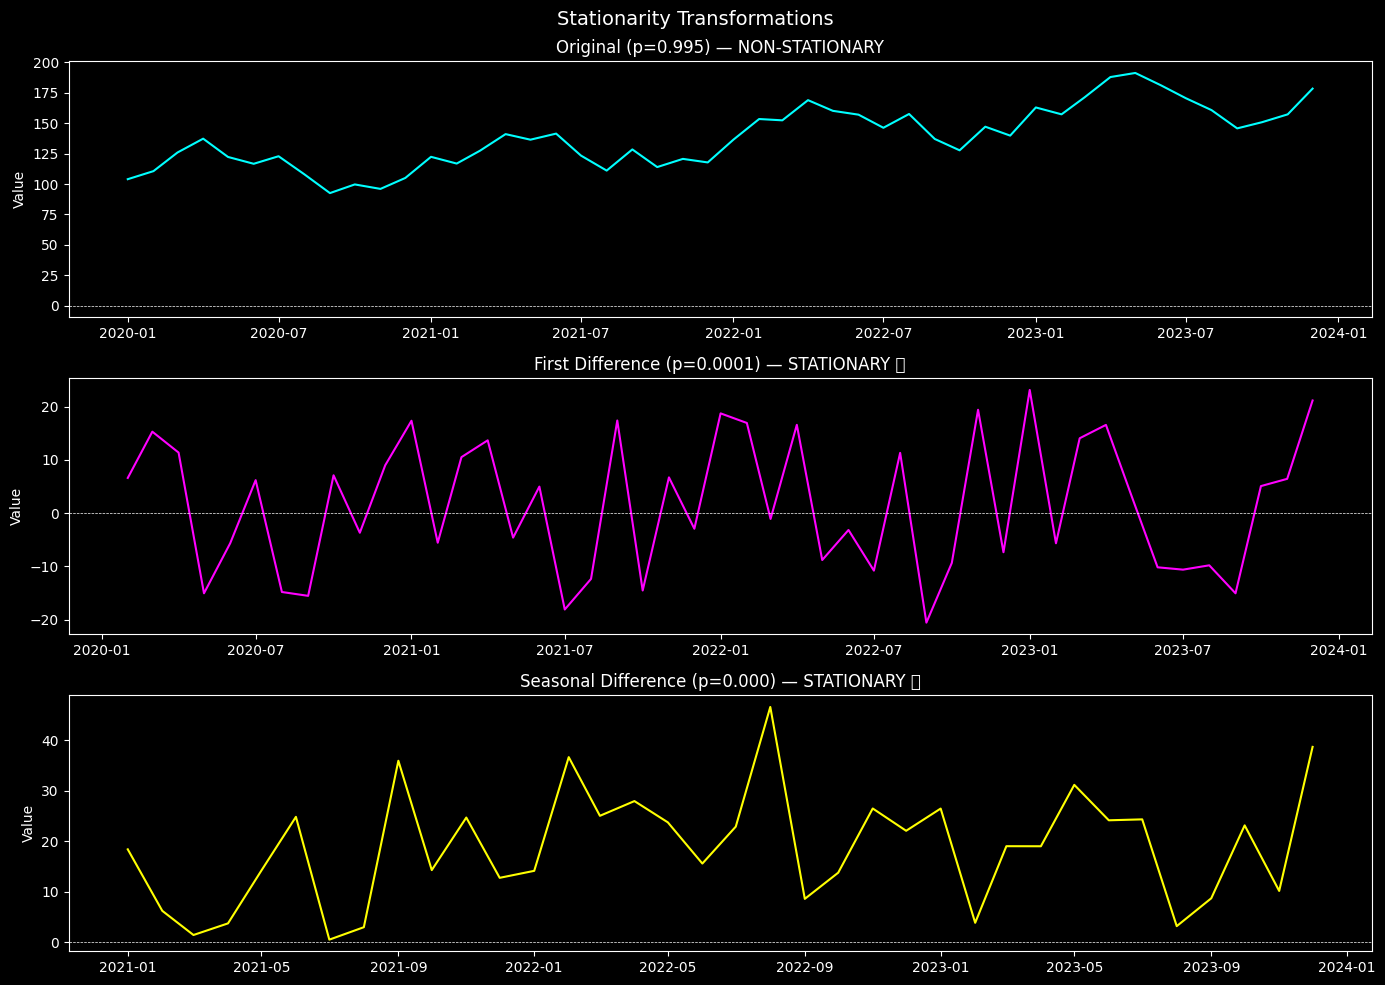

In [ ]:
print("=" * 55)
print("      STATIONARITY & ADF TEST")
print("=" * 55)
print("""
STATIONARITY = statistical properties don't change over time
  - Constant mean
  - Constant variance
  - No trend or seasonality

WHY IT MATTERS:
  ARIMA and most classical time series models REQUIRE
  stationary input. Non-stationary data must be
  transformed first (differencing, log transform).

ADF TEST (Augmented Dickey-Fuller):
  H0: Series HAS a unit root → NON-stationary
  H1: Series is STATIONARY

  p-value < 0.05 → Reject H0 → STATIONARY ✅
  p-value > 0.05 → Fail to reject H0 → NON-STATIONARY ❌
""")


def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Critical values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] < 0.05:
        print(f"  Result: STATIONARY ✅ (p={result[1]:.4f} < 0.05)")
    else:
        print(f"  Result: NON-STATIONARY ❌ (p={result[1]:.4f} > 0.05)")
    return result[1]


# Test original series
p_orig = adf_test(ts, "Original Series")

# First differencing — removes trend
ts_diff = ts.diff().dropna()
p_diff = adf_test(ts_diff, "First Differenced Series")

# Seasonal differencing — removes seasonality
ts_seasonal_diff = ts.diff(12).dropna()
p_seasonal = adf_test(ts_seasonal_diff, "Seasonally Differenced (lag=12)")

# Plot transformations
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Stationarity Transformations", fontsize=14)

for ax, (data, title, color, p) in zip(
    axes,
    [
        (ts, f"Original (p={p_orig:.3f}) — NON-STATIONARY", "cyan", p_orig),
        (
            ts_diff,
            f'First Difference (p={p_diff:.4f}) — {"STATIONARY ✅" if p_diff<0.05 else "NON-STATIONARY ❌"}',
            "magenta",
            p_diff,
        ),
        (
            ts_seasonal_diff,
            f'Seasonal Difference (p={p_seasonal:.3f}) — {"STATIONARY ✅" if p_seasonal<0.05 else "NON-STATIONARY ❌"}',
            "yellow",
            p_seasonal,
        ),
    ],
):
    ax.plot(data.index, data.values, color=color, linewidth=1.5)
    ax.axhline(0, color="white", linewidth=0.5, linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

## 5. ARIMA Forecasting

          ARIMA FORECASTING

ARIMA = AutoRegressive Integrated Moving Average

ARIMA(p, d, q):
  p = AR order: how many past VALUES to use
  d = differencing: how many times to difference
  I = Integrated: the differencing step
  q = MA order: how many past ERRORS to use

AR (AutoRegressive): y_t = c + φ₁y_{t-1} + φ₂y_{t-2} + ε_t
  Use past values to predict future

MA (Moving Average): y_t = c + θ₁ε_{t-1} + θ₂ε_{t-2} + ε_t
  Use past forecast errors to predict future

COMBINED ARIMA(1,1,1):
  Difference once (d=1) → stationary
  Use 1 past value (p=1)
  Use 1 past error (q=1)

HOW TO CHOOSE p AND q:
  ACF plot → helps choose q (MA order)
  PACF plot → helps choose p (AR order)

Train: 36 months (2020-01-01 to 2022-12-01)
Test:  12 months (2023-01-01 to 2023-12-01)

ARIMA(2,1,2) fitted!
AIC: 279.28

Forecast Metrics:
  MAE:  27.52
  RMSE: 30.86
  MAPE: 15.8%


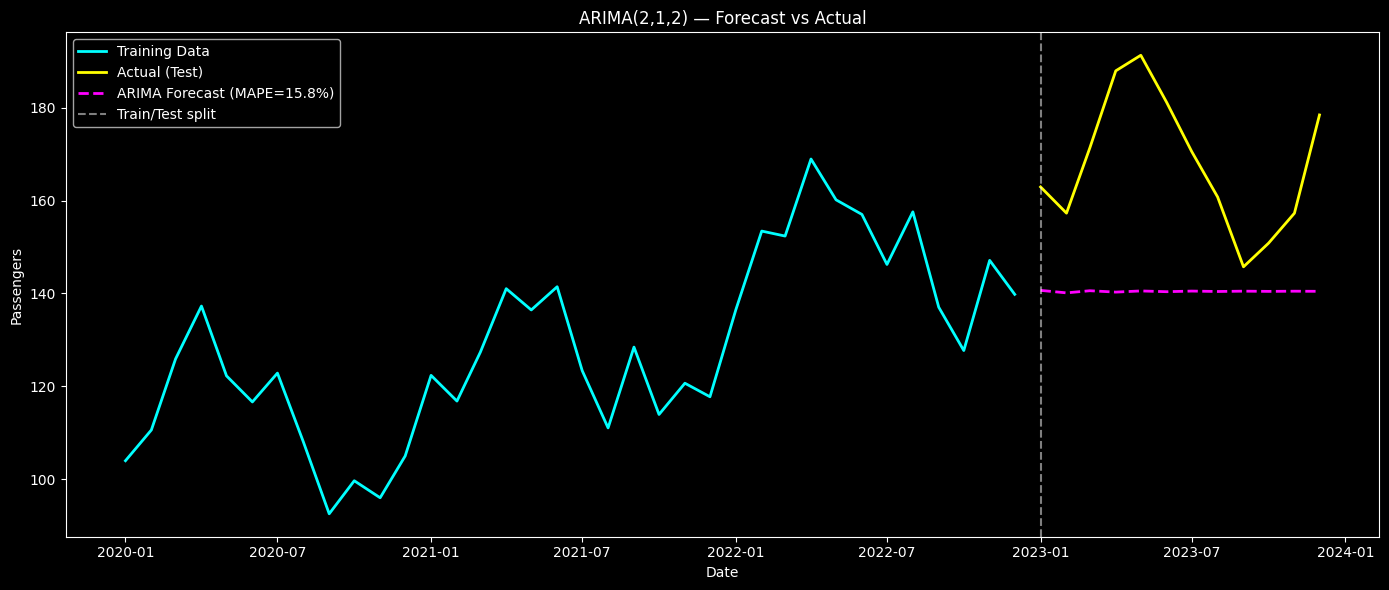


Month           Actual     Forecast     Error
---------------------------------------------
2023-01-01      162.9      140.7        +22.3
2023-02-01      157.3      140.1        +17.2
2023-03-01      171.4      140.6        +30.8
2023-04-01      188.0      140.3        +47.7
2023-05-01      191.3      140.5        +50.8
2023-06-01      181.2      140.4        +40.8
2023-07-01      170.6      140.5        +30.0
2023-08-01      160.8      140.4        +20.4
2023-09-01      145.7      140.5        +5.2
2023-10-01      150.8      140.5        +10.4
2023-11-01      157.3      140.5        +16.8
2023-12-01      178.5      140.5        +38.0


In [ ]:
print("=" * 55)
print("          ARIMA FORECASTING")
print("=" * 55)
print("""
ARIMA = AutoRegressive Integrated Moving Average

ARIMA(p, d, q):
  p = AR order: how many past VALUES to use
  d = differencing: how many times to difference
  I = Integrated: the differencing step
  q = MA order: how many past ERRORS to use

AR (AutoRegressive): y_t = c + φ₁y_{t-1} + φ₂y_{t-2} + ε_t
  Use past values to predict future

MA (Moving Average): y_t = c + θ₁ε_{t-1} + θ₂ε_{t-2} + ε_t
  Use past forecast errors to predict future

COMBINED ARIMA(1,1,1):
  Difference once (d=1) → stationary
  Use 1 past value (p=1)
  Use 1 past error (q=1)

HOW TO CHOOSE p AND q:
  ACF plot → helps choose q (MA order)
  PACF plot → helps choose p (AR order)
""")

# Train/test split — ALWAYS time-based!
train = ts[:"2022-12-01"]
test = ts["2023-01-01":]

print(
    f"Train: {len(train)} months ({train.index[0].date()} to {train.index[-1].date()})"
)
print(f"Test:  {len(test)} months ({test.index[0].date()} to {test.index[-1].date()})")

# Fit ARIMA
model = ARIMA(train, order=(2, 1, 2))
fitted = model.fit()
print(f"\nARIMA(2,1,2) fitted!")
print(f"AIC: {fitted.aic:.2f}")

# Forecast
forecast_steps = len(test)
forecast = fitted.forecast(steps=forecast_steps)
forecast_index = test.index

# Metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f"\nForecast Metrics:")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAPE: {mape:.1f}%")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, color="cyan", label="Training Data", linewidth=2)
plt.plot(test.index, test.values, color="yellow", label="Actual (Test)", linewidth=2)
plt.plot(
    forecast_index,
    forecast.values,
    color="magenta",
    label=f"ARIMA Forecast (MAPE={mape:.1f}%)",
    linewidth=2,
    linestyle="--",
)
plt.axvline(
    pd.Timestamp("2023-01-01"),
    color="white",
    linestyle="--",
    alpha=0.5,
    label="Train/Test split",
)
plt.title("ARIMA(2,1,2) — Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

# Show actual vs forecast
print(f"\n{'Month':<15} {'Actual':<10} {'Forecast':<12} {'Error'}")
print("-" * 45)
for date, act, pred in zip(test.index, test.values, forecast.values):
    error = act - pred
    print(f"{str(date.date()):<15} {act:<10.1f} {pred:<12.1f} {error:+.1f}")

## 6. Key Takeaways — Day 28 🎯

### What is Time Series?
- Sequential data collected at regular intervals
- Order MATTERS — cannot shuffle!
- Cannot use future data to predict past (leakage!)
- Always use TIME-BASED train/test split

### Four Components
- **Trend:** long-term direction (up/down/flat)
- **Seasonality:** repeating patterns at fixed intervals
- **Cyclical:** longer irregular fluctuations
- **Residual:** random noise

### Our Seasonal Pattern
- Peak months: April (+22.9), May (+18.0), June (+13.4)
- Trough months: October (-19.9), December (-16.3)
- Summer travel season clearly visible!

### Stationarity
- **Stationary:** constant mean, variance, no trend
- ARIMA requires stationary input
- ADF Test: p < 0.05 → stationary
- Original series: p=0.995 → NON-STATIONARY ❌
- First difference: p=0.0001 → STATIONARY ✅
- Seasonal difference: p=0.000 → STATIONARY ✅

### ARIMA(p, d, q)
- **p (AR):** number of past values to use
- **d (I):** number of differencing steps
- **q (MA):** number of past errors to use
- d=1 = one differencing to achieve stationarity
- ACF → choose q | PACF → choose p

### ARIMA Results
- ARIMA(2,1,2): MAPE=15.8% — decent but flat forecast!
- Missing seasonality → all errors positive (underestimates peaks)
- Fix: SARIMA = ARIMA(p,d,q)(P,D,Q)[12] for monthly seasonality

### Rolling Statistics
- `ts.rolling(12).mean()` — 12-month rolling mean (trend)
- `ts.rolling(12).std()` — 12-month rolling std (volatility)
- `ts.diff()` — first difference (removes trend)
- `ts.diff(12)` — seasonal difference (removes seasonality)

### statsmodels Functions
- `seasonal_decompose(ts, model='additive', period=12)`
- `adfuller(ts)` — ADF stationarity test
- `ARIMA(ts, order=(p,d,q)).fit()` — fit ARIMA model
- `fitted.forecast(steps=12)` — 12-step ahead forecast
- `fitted.aic` — model quality (lower = better)
- `plot_acf(ts)` — autocorrelation function plot
- `plot_pacf(ts)` — partial autocorrelation function plot